# 📊 Grupo 2: Visualización Estadística





## 🧩 **1. ¿Qué parte del reto resuelve el grupo?**  


## 📊 Resumen — Visualización Estadística

---

### Los 6 gráficos principales

| Gráfico | Para qué sirve | Cuándo usarlo |
|---|---|---|
| **Histograma** | Ver cómo se reparten los valores | Una variable numérica |
| **Boxplot** | Ver rango, mediana y outliers | Comparar grupos |
| **Scatter** | Ver si dos variables se relacionan | Dos variables numéricas |
| **Barplot** | Comparar categorías | Una numérica + una categórica |
| **Pie Chart** | Muestra proporciones de un total | una variable categórica |


---

### Las 3 reglas de oro

1. **Siempre etiqueta** los ejes y pon título
2. **Interpreta** lo que ves, no solo las graficas
3. **Elige el gráfico según la pregunta**, no por estética

---

### Lo que debes leer en cada gráfico

- **Histograma** → ¿Dónde está el pico? ¿Hay cola larga?
- **Boxplot** → ¿Dónde está la mediana? ¿Hay puntos sueltos (outliers)?
- **Scatter** → ¿Los puntos forman una diagonal? ¿O están dispersos?
- **Pie Chart** → ¿Cual es el trozo de tarta más grande?
- **Barplot** → ¿Que barra destaca más?
---

> 💡 Para nuestro reto: **histograma** para población, **boxplot** para población por región, **scatter** para área vs población por región, **barplot** para poblacion por paises, **pie chart** para monedas por paises

## 🧠 **2. Tres conceptos clave**  


### 📈 1. Histograma — ¿Cómo están repartidos los valores?
Agrupa los datos en rangos y muestra cuántos caen en cada uno.
Lo que buscas: dónde está el pico (valor más común) y si hay cola larga (outliers).
> Úsalo cuando tienes **una sola variable numérica**.

---

### 📦 2. Boxplot — ¿Dónde está la mitad y quién se sale del patrón?
El boxplot muestra la mediana (es la línea dentro de la caja), los cuartiles que delimitan la mayoría de los datos, y los outliers que representan valores raros/extremos que aparecen como puntos sueltos fuera de caja.
Lo que buscas: si hay grupos muy distintos entre sí y quién se sale del patrón.
> Úsalo cuando quieres **comparar una variable entre varios grupos**.

---

### 🔵 3. Scatter — ¿Dos variables van de la mano?
Un gráfico de puntos para ver relación entre dos variables.
Pone dos variables numéricas en los ejes X e Y, dibujando un punto por cada observación. Sirve para ver si existe una **relación** entre las variables. Si los puntos forman una nube con pendiente, hay correlación.
Lo que buscas: si cuando una variable sube, la otra también (o baja).
> Úsalo cuando tienes **dos variables numéricas** y quieres ver si se relacionan.

> ⚠️ **Importante:** que dos variables se relacionen en un scatter
> **no significa que una cause la otra**.

---
### 🍰 4. Pie Chart - ¿Qué parte representa cada categoría?
Muestra cómo se reparte un total entre varias categorías.
Cada porción del círculo es una proporción del total (porcentaje).
Lo que buscas: qué categoría es la más grande, cuál es la más pequeña y cómo se comparan entre sí.
> Úsalo cuando quieres mostrar proporciones de una variable categórica (por ejemplo, porcentaje de países por región).


---

### 📊 5. Barplot -  ¿Quién tiene más y quién tiene menos?
Compara cantidades entre categorías.
Cada barra representa una categoría y su altura indica cuánto tiene.
Lo que buscas: diferencias claras entre grupos, cuál destaca y cuál queda atrás.
> Úsalo cuando quieres comparar valores entre categorías (por ejemplo, número de países por región o población media por continente).

---





## 💻 **3. Consumo de API + creación del DataFrame**  

- Conexión a una API pública  
- Transformación de los datos en un DataFrame  


In [ ]:
%matplotlib inline 

import requests          # Para hacer peticiones a la API
import numpy as np       # Para cálculos numéricos
import pandas as pd      # Para crear y manejar el DataFrame
import matplotlib.pyplot as plt  # Para gráficas básicas
import seaborn as sns    # Para gráficas más visuales
import sqlite3
from scipy import stats  # Para estadística y pruebas de hipótesis


# URL de la API con los campos que nos interesan
url = "https://restcountries.com/v3.1/all?fields=name,capital,currencies,languages,region,population,area"
response = requests.get(url, timeout=20)  # Hacemos la petición a la API (máximo 20s de espera)
response.raise_for_status()               # Si hay error de conexión, lo lanza aquí
data = response.json()                    # Convertimos la respuesta a una lista de diccionarios
rows = []  # Lista vacía donde iremos guardando cada país como diccionario
for c in data:  # Recorremos cada país (c = un país en formato diccionario)
    capital_list = c.get("capital", [])    # "capital" es una lista, puede venir vacía
    population = c.get("population")       # Número de habitantes (entero)
    area = c.get("area")                   # Superficie en km² (decimal)
    # Calculamos densidad de población (habitantes por km²)
    # Evitamos dividir por cero o por None
    if population and area and area > 0:
        density = round(population / area, 2)  # Redondeamos a 2 decimales
    else:
        density = None  # Si faltan datos, dejamos vacío
        
    

    rows.append({  # Añadimos el país a la lista como diccionario
        "name":       c.get("name", {}).get("common"),       # Nombre está anidado: name → common
        "capital":    capital_list[0] if capital_list else None,  # Primer elemento si existe
        "region":     c.get("region"),                       # Continente o región del mundo
        "population": population,                            # Habitantes
        "area":       area,                                  # Superficie en km²
        "density":    density,                               # Habitantes por km² (calculado)
        "currencies": ", ".join(c.get("currencies", {}).keys()),   # Códigos de moneda: EUR, USD...
        "languages":  ", ".join(c.get("languages", {}).values()),  # Nombres de idiomas: Spanish...
    })
df = pd.DataFrame(rows)  # Convertimos la lista de diccionarios en una tabla (DataFrame)






In [62]:
numeric_cols = ["population", "area"]  # Limpieza de las columnas numericas 
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=["region", "population", "area"])
df = df[df["population"] > 0]
df = df[df["area"] > 0]

# Variable derivada util para analisis
df["density"] = df["population"] / df["area"]

display(df.head(10))
print(f"\nPaises validos para analisis: {len(df)}")

df.to_csv("prueba_tabla.csv", index=False)


con = sqlite3.connect("prueba_tablas.db")

df.to_sql("prueba_tabla", con, if_exists="replace", index=False)



,name,capital,region,population,area,density,currencies,languages
0,Cook Islands,Avarua,Oceania,15040,236.0,63.728814,"CKD, NZD","English, Cook Islands Māori"
1,Guinea,Conakry,Africa,14363931,245857.0,58.423925,GNF,French
2,Christmas Island,Flying Fish Cove,Oceania,1692,135.0,12.533333,AUD,English
3,Togo,Lomé,Africa,8095498,56785.0,142.564022,XOF,French
4,Taiwan,Taipei,Asia,23317031,36197.0,644.170263,TWD,Chinese
5,Kyrgyzstan,Bishkek,Asia,7281800,199951.0,36.417922,KGS,"Kyrgyz, Russian"
6,Suriname,Paramaribo,Americas,616500,163820.0,3.763277,SRD,Dutch
7,Dominican Republic,Santo Domingo,Americas,10771504,48671.0,221.312568,DOP,Spanish
8,Guatemala,Guatemala City,Americas,18079810,108889.0,166.038902,GTQ,Spanish
9,Algeria,Algiers,Africa,47400000,2381741.0,19.901408,DZD,Arabic



Paises validos para analisis: 245


245


## 📊 **4. Ejemplos**

En esta sección se muestran visualizaciones de graficos y sus interpretaciónes



### 🍰 **Pie Chart - top monedas por número de países**


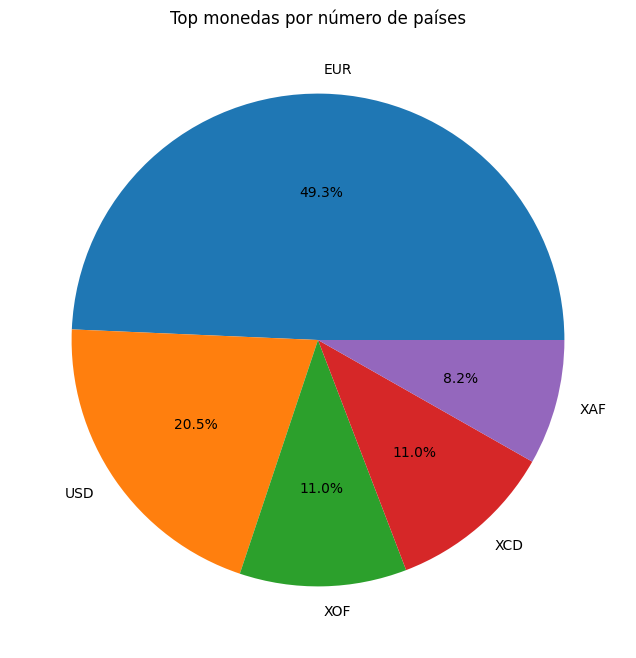

In [63]:
# Query
moneda2 = pd.read_sql("""
SELECT 
    currencies AS Moneda, 
    COUNT(*) AS Numero_Paises
FROM prueba_tabla
WHERE currencies IS NOT NULL AND currencies != ''
GROUP BY currencies
ORDER BY Numero_Paises DESC
""", con)

moneda2 = moneda2.head(5)
plt.figure(figsize=(8,8))
plt.pie(moneda2["Numero_Paises"], labels=moneda2["Moneda"], autopct="%1.1f%%")
plt.title("Top monedas por número de países")
plt.show()



**📊 Interpretación de resultados: Pie chart — Top monedas por número de países**

Los porcentajes mostrados corresponden únicamente a las monedas seleccionadas en el gráfico, por lo que representan una distribución relativa y no el total global.  
El gráfico muestra las monedas más utilizadas en función del número de países que las emplean. Se observa que un pequeño grupo de monedas concentra la mayor parte de los países, destacando especialmente aquellas compartidas por varias naciones, como el euro.

→ El euro es la moneda de mayor alcance geográfico por número de países, aunque no por volumen de población.



💡 Notas. 

🥧 Pie chart (gráfico circular)

- Sectores: cada porción representa una categoría
- Tamaño del sector: proporcional al porcentaje o cantidad
- Total: el círculo completo = 100%

⚡ En una frase
Sirve para ver cómo se divide un total en partes.

🧠 Qué puedes ver
- Qué categoría es la más grande
- Proporciones relativas entre categorías

📌 Ejemplo
Gastos:
- Comida = 40%
- Transporte = 20%
- Ocio = 40%

### 📈 **Histograma de población**

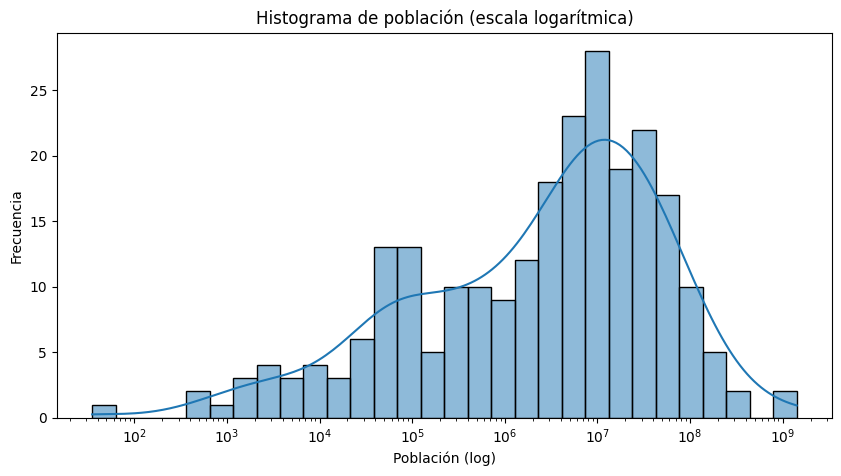

In [ ]:
df["population"] = pd.to_numeric(df["population"], errors="coerce")

df_clean = df["population"].dropna()
df_clean = df_clean[df_clean > 0]  # importante para log

plt.figure(figsize=(10,5))
sns.histplot(df_clean, bins=30, kde=True, log_scale=True)
plt.title("Histograma de población (escala logarítmica)")
plt.xlabel("Población (log)")
plt.ylabel("Frecuencia")
plt.show()

📊 **Interpretación de resultados: Histograma — Distribución de población (escala log)**

La mayoría de los países tienen entre 1 y 30 millones de habitantes.  
La distribución en escala logarítmica muestra una curva con el pico alrededor de los 10 millones de habitantes. Hay muy pocos países con menos de 10.000 personas (microestados) y también muy pocos con más de 500 millones. La distribución es asimétrica hacia la izquierda, por lo tanto es una distribucion negativamente sesgada.

→ La población de los países no está distribuida de forma uniforme. La mayoría se concentra en valores medios, mientras que hay pocos países muy pequeños y muy pocos extremadamente grandes.   
"País típico" = tamaño medio-pequeño. Los gigantes demográficos son casos extremos y excepcionales. 

💡 Notas:  

Cola (tail): es la parte alargada del histograma donde hay pocos datos.  

- Cola a la derecha → distribución con sesgo positivo.  
- Cola a la izquierda → distribución con sesgo negativo.  

Sesgo (asimetría): describe hacia qué lado se alarga la cola.  

Pico (moda): el punto donde la barra es más alta.  

Centro: donde se concentran los datos (media o mediana). 

Dispersión: qué tan extendidos están los datos.💡. 

### 🔵 **Scatter plot— Área vs Población por región**


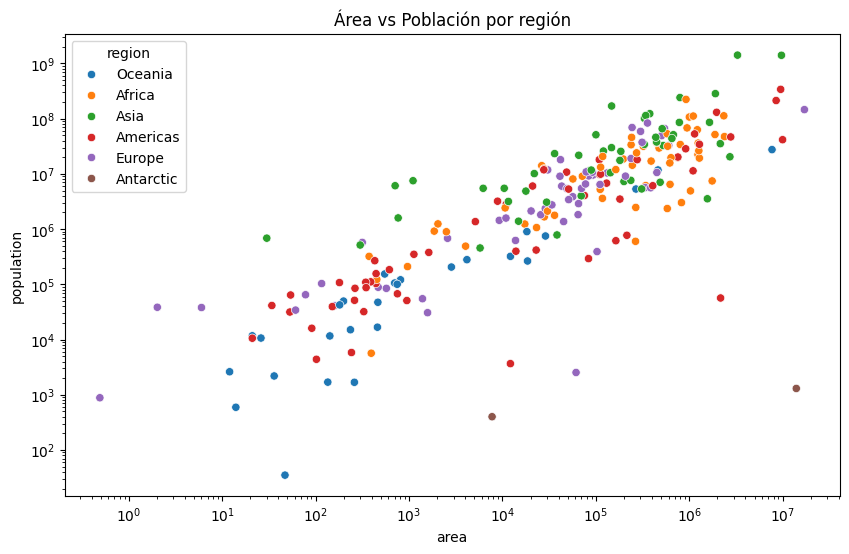

In [65]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="area",
    y="population",
    hue="region"
)

plt.xscale("log")
plt.yscale("log")

plt.title("Área vs Población por región")
plt.show()

📊 **Interpretación de resultados: Scatter plot— Área vs Población por región**

A mayor territorio, mayor población… pero con muchas excepciones.  
Existe una correlación positiva general entre superficie y población. Los países asiáticos (verde) destacan por tener alta densidad de población en territorios medianos. Algunos africanos y americanos tienen grandes territorios con poca población. Los países europeos (morado) tienden a agruparse en superficies pequeñas-medianas con poblaciones altas.

→ Mayor área tiende a más población, pero hay excepciones claras. La región importa:
Asia concentra alta densidad; Oceanía y Antártica tienen mucho territorio y poquísima gente.

 💡Notas:

📊 Gráfico de dispersión (scatter plot). 
- Puntos: cada punto representa un par de valores (x, y). 
- Eje X: una variable numérica. 
- Eje Y: otra variable numérica. 

⚡ En una frase. 
Sirve para ver la relación entre dos variables.  

🧠 Qué puedes ver. 
- Relación positiva: sube X → sube Y. 
- Relación negativa: sube X → baja Y. 
- Sin relación: puntos dispersos sin patrón. 
- Valores atípicos: puntos alejados. 

📌 Ejemplo. 
Altura vs peso → cada persona es un punto. 

### 📦 **Boxplot — Población por región**


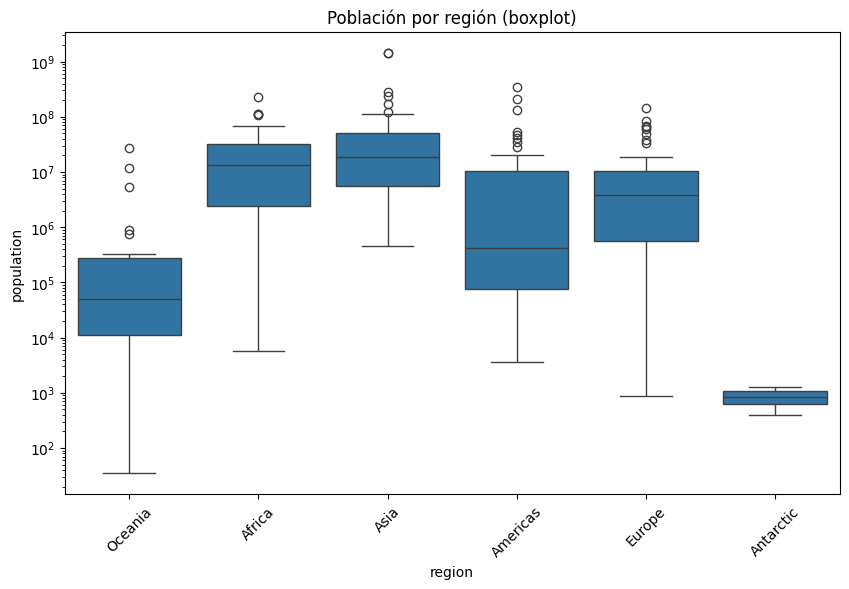

In [66]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="region", y="population")

plt.yscale("log")
plt.xticks(rotation=45)

plt.title("Población por región (boxplot)")
plt.show()

📊 **Interpretación de resultados: Boxplot — Población por región**

Asia y África lideran en población mediana, con valores en torno a los 10–20 millones. La Antártida tiene la mediana más baja (~10.000), y la menor dispersión de datos entorno a esta.
Las regiones (a excepción de la Antártida) presentan gran dispersión de datos con un alto números de paises considerados estadisticamente outliers en todo los caso por encima del máximo de la región

→ Los muchos círculos fuera de los bigotes (outliers) confirman que los gigantes demográficos son anomalías estadísticas en todas las regiones. 

💡 Notas: 

Un boxplot (o diagrama de caja y bigotes) es una forma rápida de resumir cómo se distribuyen los datos.  

📦 Partes principales. 
Caja (box): va desde el primer cuartil (Q1) al tercer cuartil (Q3)  
→ aquí está el 50% central de los datos.  

Línea dentro de la caja: la mediana (valor central).  

Bigotes (whiskers): se extienden desde la caja hacia:  
el valor mínimo  
el valor máximo  
(a veces limitados para detectar valores raros).  

Puntos fuera de los bigotes: valores atípicos (outliers).  

⚡ En una frase:  
El boxplot te muestra centro, dispersión y valores extremos de un vistazo.  

### 📊 **Barplot — Top 10 países por población**


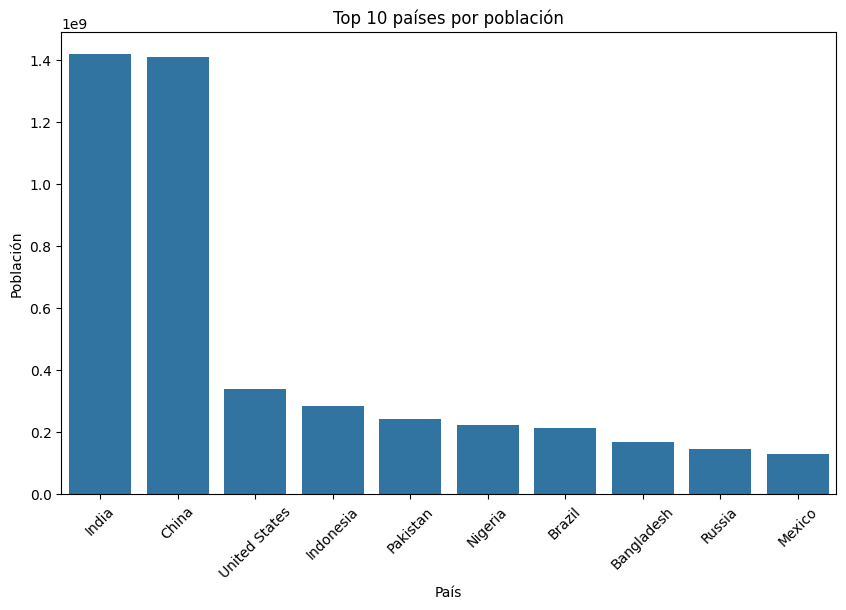

In [67]:
top_paises = df.sort_values(by="population", ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(data=top_paises, x="name", y="population")

plt.title("Top 10 países por población")
plt.xlabel("País")
plt.ylabel("Población")
plt.xticks(rotation=45)

plt.show()

📊 **Interpretación de resultados: Barplot — Top 10 países por población**

India y China con 1400 millones de personas cada uno, son los paises con mayor población en el mundo, seguidos por USA cuyo número de habitantes es menos de un tercio de la poblacion de su predecesor.  
Completan el top 10:Indonesia, Pakistán, Nigeria, Brasil, Bangladés, Rusia y México. 

→ Los dos primeros países concentran por sí solos aproximadamente el 35% de la población mundial.  

💡 Notas:

Un barplot (o gráfico de barras) es una forma simple de comparar cantidades entre categorías.  

📊 Partes principales:  

Barras: cada barra representa una categoría.  
Altura de la barra: indica el valor (frecuencia, porcentaje, cantidad, etc.).  
Eje X: las categorías (por ejemplo: colores, países, tipos…).  
Eje Y: los valores numéricos.  

⚡ En una frase:  
El barplot sirve para comparar fácilmente cuánto hay de cada cosa. 
 
🧠 Ejemplo. 
Si tienes:   
Rojo = 10.  
Azul = 5.  
Verde = 8.   
  → la barra de “Rojo” será la más alta.   

# **Conclusiones globales**

1. **Desigualdad demográfica extrema**: Dos países (India y China) concentran más de un tercio de la poblacion.
2. **El país "medio" es pequeño**: La mayoría de los ~195 países del mundo tienen menos de 20 millones de habitantes.
3. **Territorio ≠ población**: La correlación existe pero es débil; la densidad varía enormemente entre regiones.
4. **El euro lidera en alcance geográfico**: Es la moneda de más países, aunque no la más usada por número de personas.
5. **Asia es el continente demográfico dominante**: Mayor mediana de población y mayor concentración de países densamente poblados.


## ⚠️ **5. Errores frecuentes y cómo evitarlos**


1. Usar mal los campos de la API  
No especificar correctamente los `fields` puede hacer que los datos no se devuelvan o aparezcan como `None`.

2. Usar un gráfico incorrecto para el tipo de variable  
Ejemplo: usar histograma con variables categóricas no numericas.

3. No usar escala logarítmica en datos muy grandes  
En variables como población, los valores son muy grandes y pueden ocultar patrones si no se usa escala log.





## 🔗 **6. Conexión con otros grupos**  

<p>👀Para concretar éste trabajo colectivo bajo este prisma, ⭐debemos dejar de ver las estrellas como puntos de luz lejanos y empezar a verlas como nodos de una red neuronal compartida 🪐, diseñada para transformar la voluntad individual en un acto de prestidigitación colectiva.

Para que el trabajo avance, los equipos deben operar bajo la ilusión de que no hay distancias. Las estrellas no son un testigo, son los espejos donde todos nos miramos al mismo tiempo.✨​​​🎭​

Imagina que cada equipo proyecta su objetivo hacia una estrella guía. En el ilusionismo, si todos miran al mismo punto, el truco sucede.</p>

<h2>💫 Sincronia de intención 💫​ </h2>

 **En el trabajo:** Cuando el equipo define el "Norte" del proyecto, esa estrella se vuelve el depósito de nuestra energía. Si alguien se pierde, solo tiene que mirar hacia arriba (o hacia el propósito compartido) para recordar dónde están los demás. ​🌟​

<h2>​​​​​🧠​☁️ ​Comunicación intrasensorial ​​​​​​​​​☁️🧠​​​</h2>

Aquí es donde ocurre la magia​​​​🧙​. Visualiza que de esa estrella caen hilos de luz invisibles ​​​​🌈​ que se conectan directamente a la punta de tus dedos y a los de tus compañeros.​​​​

**La sensación:** ​🩺​No necesitas preguntar __"¿cómo vas?".__ Al tocar tu teclado o tu herramienta, sientes la __"tensión"__ del hilo de tu compañero.​​​​​

**El efecto:** Si un colega está bajo presión, tú sientes una vibración sutil, un cambio de temperatura en tu propio espacio.🔥​ La respuesta no es un email, es una acción compensatoria inmediata para equilibrar la red.​

<h2> ​​🎼​🥁​ La partitura del silencio ​​🥁🎼​</h2>

Los mejores ilusionistas no necesitan hablar para coordinarse. En una conexión estelar, el equipo desarrolla una frecuencia de radio interna.​​🎙️​

**Concreción:** El trabajo deja de ser una suma de tareas y se convierte en una coreografía. Sabes cuándo entrar y cuándo retirarte porque escuchas el "pulso" de la estrella, que marca el ritmo del proyecto para todos por igual.

<h2>​​​🤯​ La Ilusión final: La desesperación del "Yo" ​​​🤯​</h2>
El truco maestro de esta conexión es que, al final del día, el equipo ya no siente que está haciendo un esfuerzo individual. El trabajo "aparece" como por arte de magia porque todos movieron sus manos al unísono, guiados por la misma luz fría y perfecta.

**Regla de Oro:** En este nivel de conexión, el éxito no es de quien sostiene la varita, sino de la constelación completa que permitió que la luz fluyera.

 ****Newton****